# Результаты

**Шкалирование данных** необходимо для точного вычисления расстояний между точками и приведением значений в единую шкалу. Иначе из-за особенностей работы с плавающей точкой потеряется точность и результат может исказиться.

Данные выделяются в кластера, но кластера в основе своей разнообразны и в некоторой степени похожи.
Выглядит так, будто ***данные*** на самом деле ***принадлежат одному кластеру*** потребительских кредитов.

В пользу этой теории говорит то, что DBSCAN создает крайне много кластеров. При большом эпсилон DBSCAN выделяет один большой кластер, очень маленький второй кластер и очень малый кластер выбросов.

In [187]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

path = kagglehub.dataset_download("uciml/german-credit")

source_data = pd.read_csv(f"{path}/german_credit_data.csv")
source_data.drop(source_data.columns[[0]], inplace=True, axis=1)

categorical_features = [
    "Sex", 
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
]

numerical_features = [
    "Age",
    "Credit amount",
    "Duration",
]

features_to_drop = [
]

# Убираем NA т.к. неизвестно чем заполнять. Можно проставить незначащее значение NONE, но оно может исказить картину
source_data.dropna(inplace=True)
# source_data.fillna("NONE")

data = source_data.copy(deep=True)

data.info()
print("=" * 100)
print(data.isna().sum())
print("=" * 100)
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Purpose           522 non-null    object
dtypes: int64(4), object(5)
memory usage: 40.8+ KB
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,22,female,2,own,little,moderate,5951,48,radio/TV
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
7,35,male,3,rent,little,moderate,6948,36,car
9,28,male,3,own,little,moderate,5234,30,car


In [188]:
# Удаляем то что не обрабатываем
for col in features_to_drop:
    data.drop(col, axis=1, inplace=True)
# Превращаем все категориальные данные в матрицу значений
for col in categorical_features:
    data = data.join(pd.get_dummies(data[col], prefix=col+'_'))
    data = data.drop(col, axis=1)
# Превращаем все численные данные в стандартизированные
for col in numerical_features:
    scaler = MinMaxScaler()
    data[col] = scaler.fit_transform(data[col].to_numpy().reshape(-1, 1))

data.head()

,Age,Credit amount,Duration,Sex__female,Sex__male,Job__0,Job__1,Job__2,Job__3,Housing__free,Housing__own,Housing__rent,Saving accounts__little,Saving accounts__moderate,Saving accounts__quite rich,Saving accounts__rich,Checking account__little,Checking account__moderate,Checking account__rich,Purpose__business,Purpose__car,Purpose__domestic appliances,Purpose__education,Purpose__furniture/equipment,Purpose__radio/TV,Purpose__repairs,Purpose__vacation/others
1,0.053571,0.312707,0.636364,True,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
3,0.464286,0.419110,0.545455,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False
4,0.607143,0.253141,0.272727,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False
7,0.285714,0.367644,0.454545,False,True,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
9,0.160714,0.273198,0.363636,False,True,False,False,False,True,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False


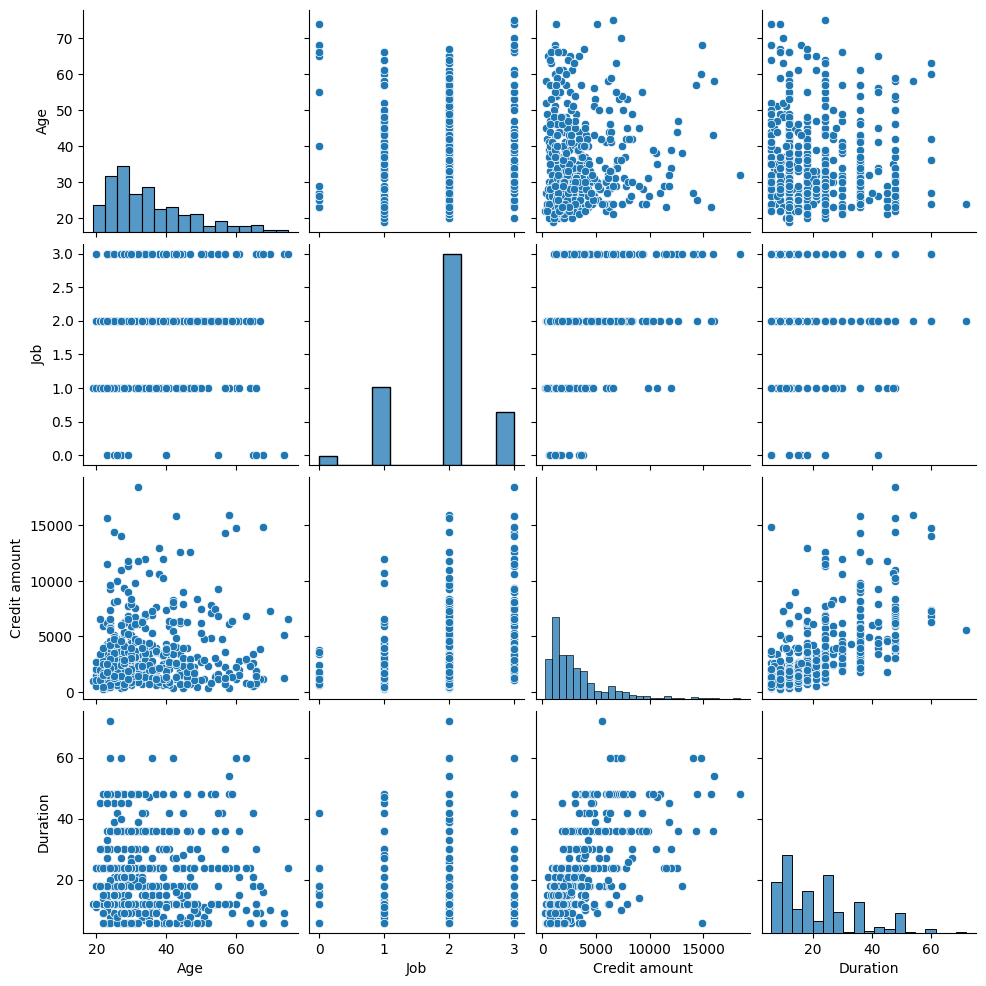

In [146]:
sns.pairplot(source_data)

<Axes: >

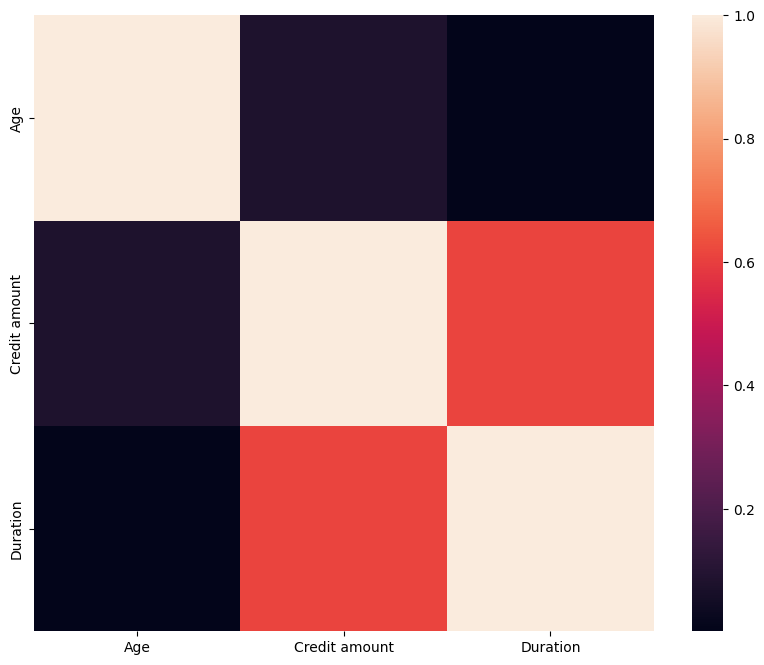

In [189]:
correlation_threshold = .85 # Значение корреляции, которые мы считаем сильным

correlated_columns = dict() # Колонки, которые коррелируют между собой

corr_data = source_data[numerical_features].corr()

for column in corr_data.columns:
    values_bigger_than_threshold = corr_data[column][corr_data[column] > correlation_threshold]
    correlated_columns[column] = list(values_bigger_than_threshold.index)
    correlated_columns[column].remove(column)
    
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data)

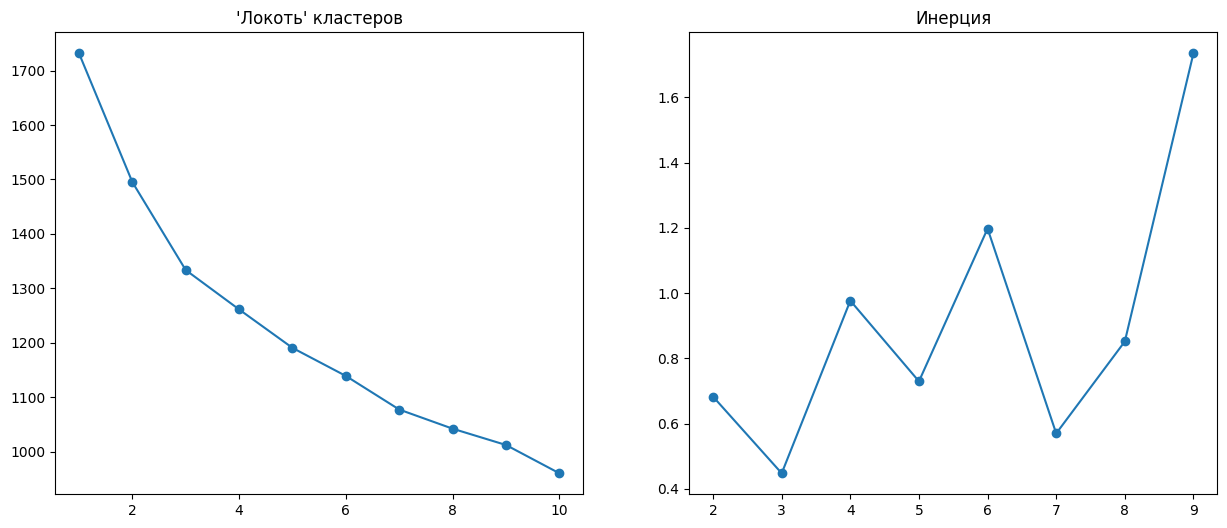

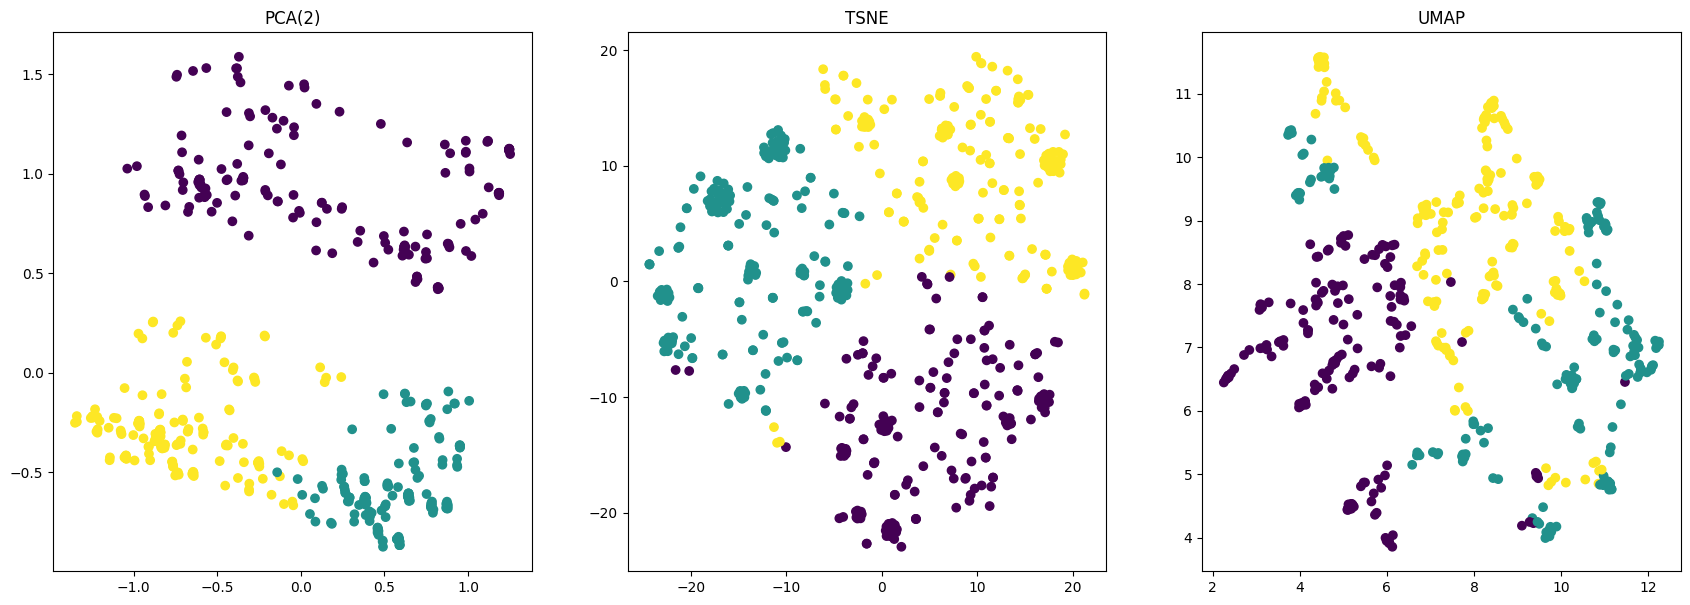

In [190]:
def show_clusters(X, labels, reducer=None, axis=plt):
    if reducer:
        X_reduced = reducer.fit_transform(X)
        axis.scatter(X_reduced[:,0], X_reduced[:,1], c=labels)
    else:
        _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))
        show_clusters(data, labels, reducer=PCA(n_components=2), axis=ax1)
        ax1.set_title("PCA(2)")
        show_clusters(data, labels, reducer=TSNE(), axis=ax2)
        ax2.set_title("TSNE")
        show_clusters(data, labels, reducer=umap.UMAP(), axis=ax3)
        ax3.set_title("UMAP")
    
def elbow_plot(X, max_clusters=10, **model_params):
    inertia = []
    for i in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=i, **model_params).fit(X)
        inertia_i = kmeans.inertia_
        inertia.append(inertia_i)
    
    D = []
    min_D_index = 0
    min_D = float("inf")
    for i in range(1, max_clusters-1):
        Di = (inertia[i] - inertia[i+1]) / (inertia[i-1] - inertia[i])
        D.append(Di)
        if Di < min_D:
            min_D = Di
            min_D_index = i
        
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.plot(range(1,max_clusters+1), inertia, marker='o')
    ax1.set_title("'Локоть' кластеров")
    ax2.plot(range(2,max_clusters), D, marker='o')
    ax2.set_title("Инерция")
    
    return min_D_index + 1

best_clusters_count = elbow_plot(data, 10, random_state=42, n_init=10)

model = KMeans(n_clusters=best_clusters_count, random_state=42, n_init=10).fit(data)

show_clusters(data, model.labels_)

data_kmeans = source_data.copy(deep=True)
data_kmeans["cluster"] = model.labels_

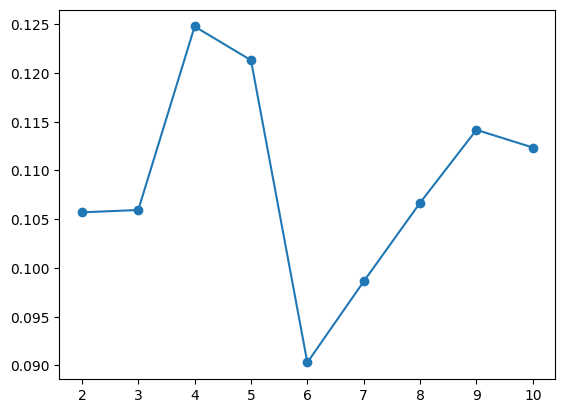

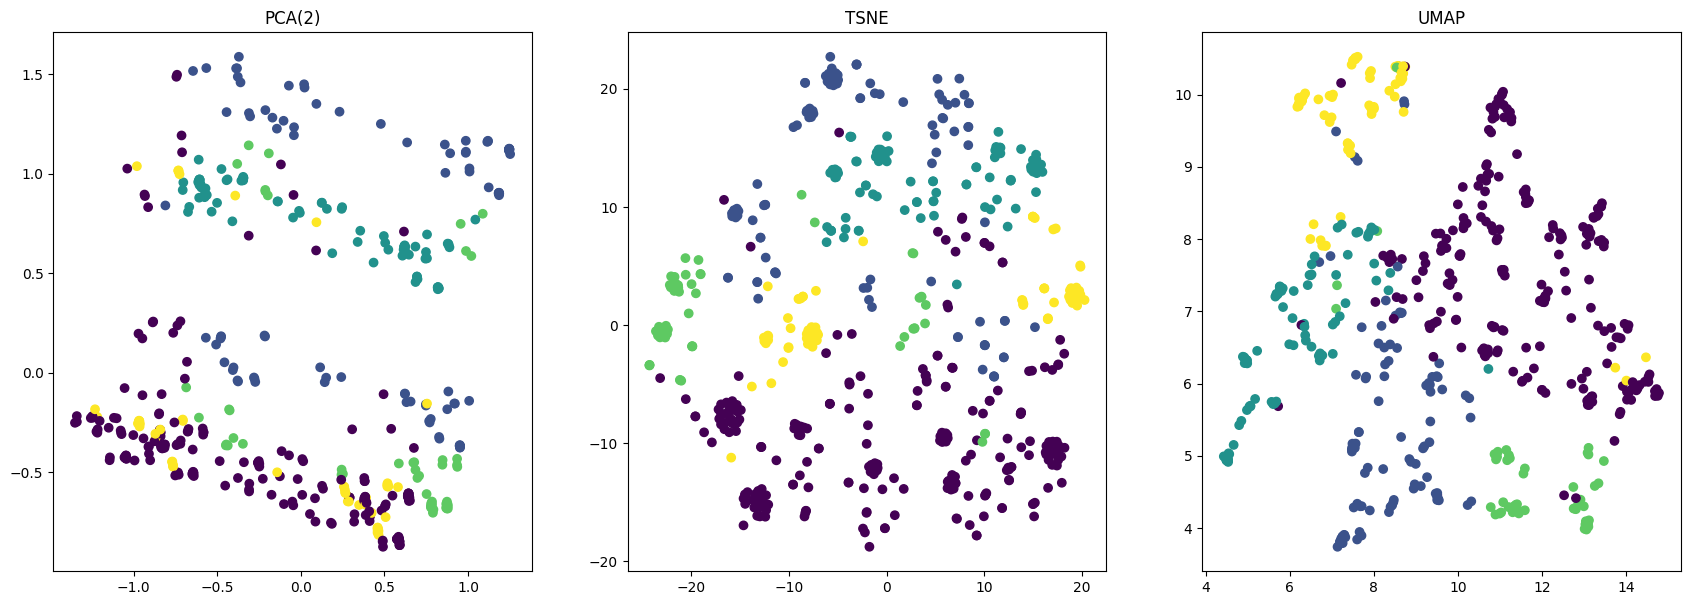

In [191]:
def silhouette_plot(X, max_clusters=10):
    silhouette = []
    max_silhouette_index = 0
    max_silhouette = float("-inf")
    for i in range(2, max_clusters+1):
        agg = AgglomerativeClustering(n_clusters=i).fit(X)
        labels = agg.labels_
        score = silhouette_score(X, labels)
        silhouette.append(score)
        if score > max_silhouette:
            max_silhouette = score
            max_silhouette_index = i
    
    plt.plot(range(2, max_clusters+1), silhouette, marker='o')
    
    return max_silhouette_index + 1

best_clusters_count = silhouette_plot(data)
model = AgglomerativeClustering(n_clusters=best_clusters_count).fit(data)
show_clusters(data, model.labels_)

data_ac= source_data.copy(deep=True)
data_ac["cluster"] = model.labels_

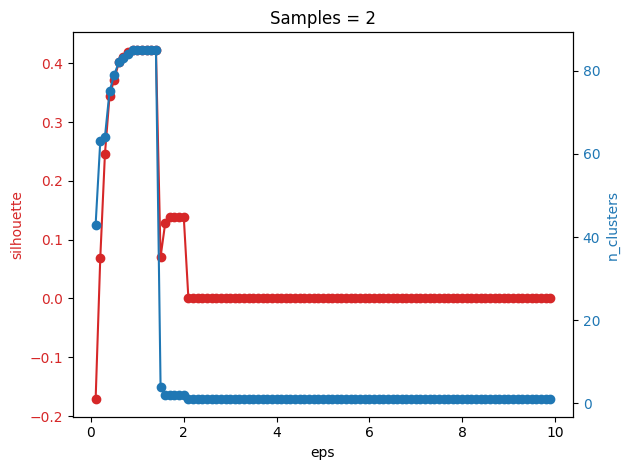

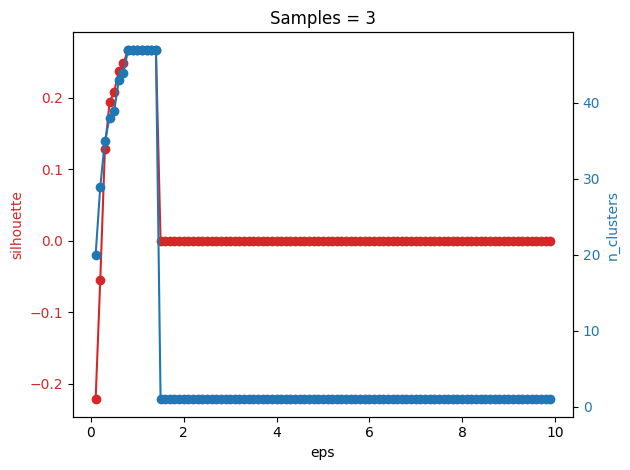

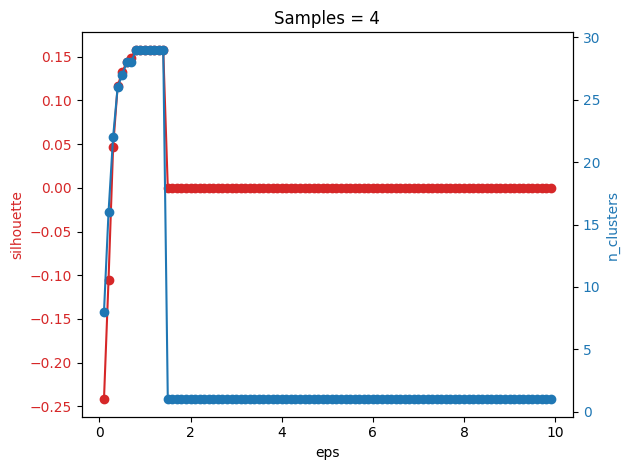

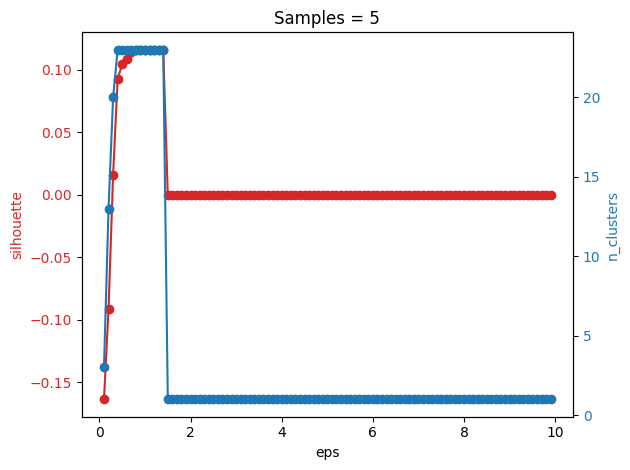

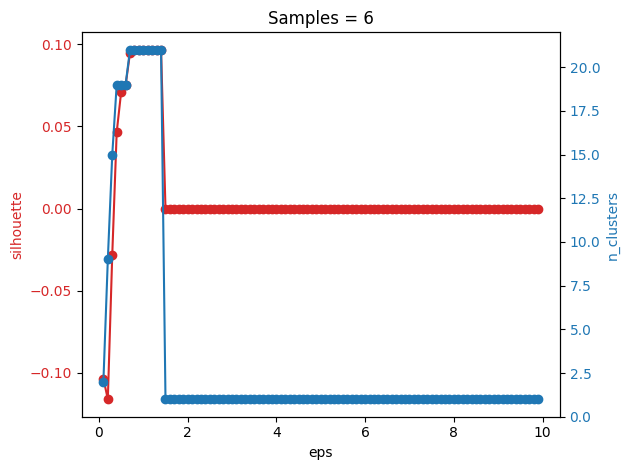

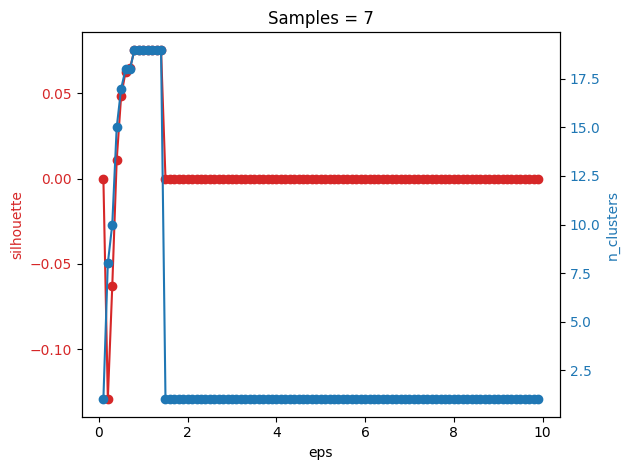

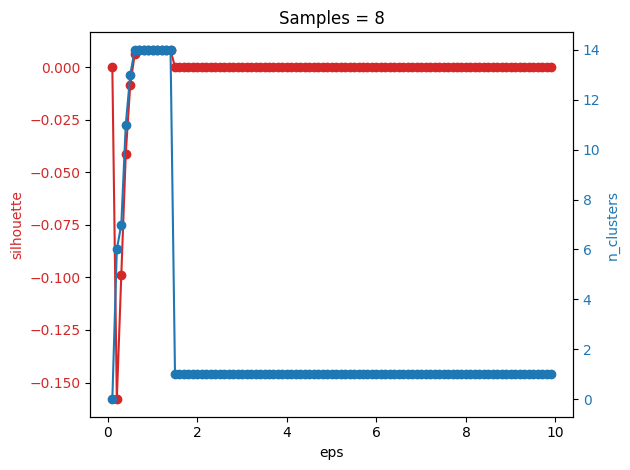

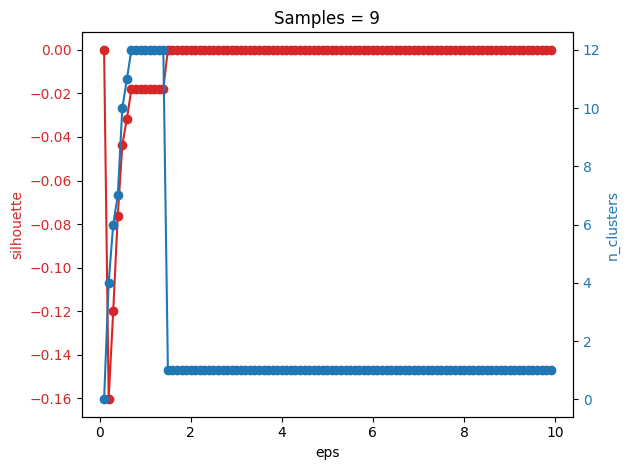

Количество кластеров: 85 при epsilon = 0.9, количество элементов = 2


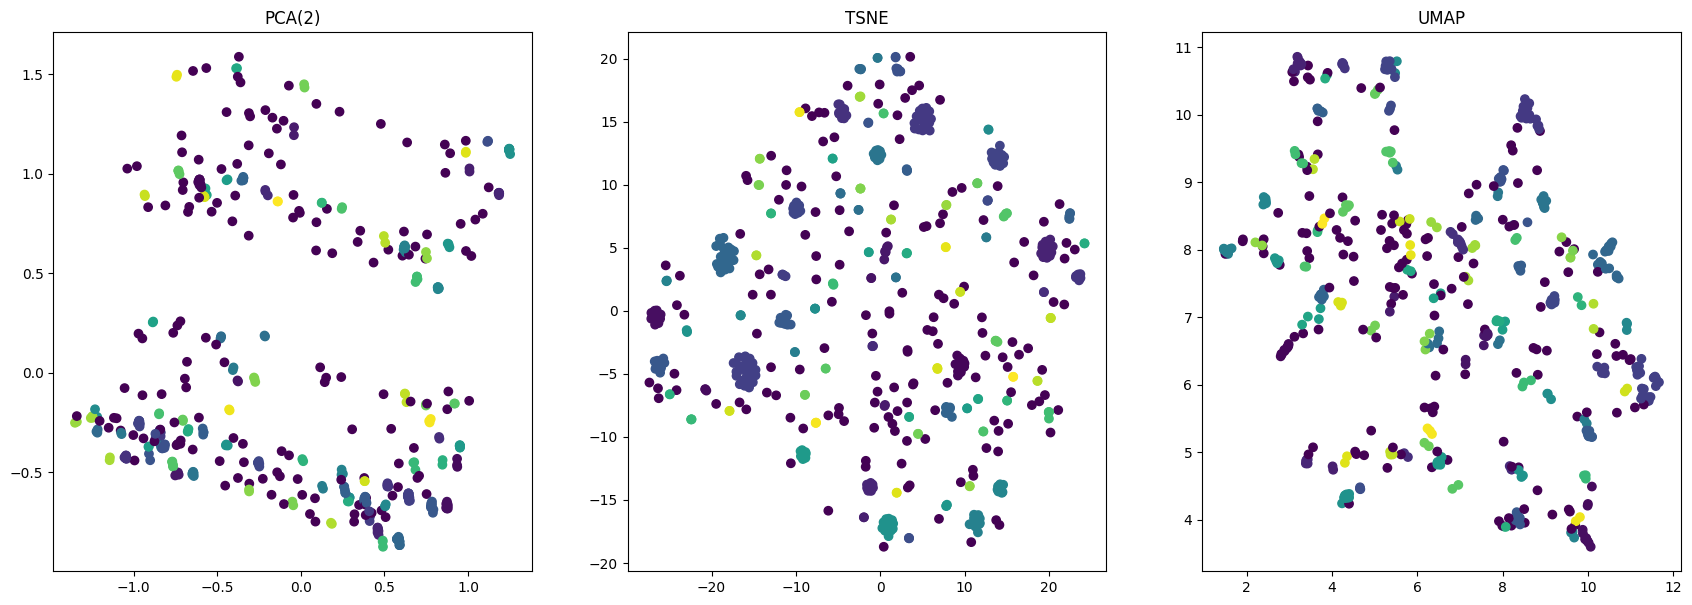

In [240]:
def calculate_silhouette(X, epsilon, samples):
    dbscan = DBSCAN(eps=epsilon, min_samples=samples).fit(X)
    labels = dbscan.labels_
    uniq_labels = np.unique(labels)
    n_clusters = len(uniq_labels[uniq_labels != -1])
    if n_clusters > 1:
        return silhouette_score(X, labels), n_clusters
    else:
        return 0, n_clusters

def silhouette_params(X, eps_range, samples_range):
    silhouette = []
    clusters = []
    
    best_eps = 0
    best_samples = 0
    max_silhouette = float("-inf")
    
    for samples in samples_range:
        samples = int(samples)
        for epsilon in eps_range:
            epsilon = float(epsilon)
            score, n_clusters = calculate_silhouette(X, epsilon, samples)
                
            if score > max_silhouette:
                max_silhouette = score
                best_eps = epsilon
                best_samples = samples
                
            silhouette.append(score)
            clusters.append(n_clusters)
            
        fig, ax1 = plt.subplots()

        plt.title(f"Samples = {samples}")
        
        color = 'tab:red'
        ax1.plot(eps_range, silhouette, marker='o', color=color)
        ax1.set_xlabel('eps')
        ax1.set_ylabel('silhouette', color=color)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

        color = 'tab:blue'
        ax2.plot(eps_range, clusters, marker='o', color=color)
        ax2.set_ylabel('n_clusters', color=color)  
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()
        
        silhouette.clear()
        clusters.clear()
    
    return best_eps, best_samples

best_eps, best_samples = silhouette_params(data, np.arange(0.1, 10, 0.1), np.arange(2, 10, 1))
# best_eps, best_samples = silhouette_params(data, np.arange(0.1, 2, 0.01), np.arange(10, 20, 1))

score, cluster_count = calculate_silhouette(data, best_eps, best_samples)
print(f"Количество кластеров: {cluster_count} при epsilon = {best_eps}, количество элементов = {best_samples}")

model = DBSCAN(eps=best_eps, min_samples=best_samples).fit(data)

show_clusters(data, model.labels_)

data_dbscan = source_data.copy(deep=True)
data_dbscan["cluster"] = model.labels_

In [193]:
source_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Purpose           522 non-null    object
dtypes: int64(4), object(5)
memory usage: 40.8+ KB


In [236]:
categorical_agg = [
    ('unique_values', lambda x: list(x.unique())),
    ('value_counts', lambda x: dict(x.value_counts())),
    'unique'
]
numerical_agg = ["mean", "min", "max", "std"]

def get_groupped_data(data):
    groupped_data = data.groupby("cluster").agg({
        "Age": numerical_agg,
        "Credit amount": numerical_agg,
        "Duration": numerical_agg,
        "Sex": categorical_agg,
        "Job": categorical_agg,
        "Saving accounts": categorical_agg,
        "Checking account": categorical_agg,
        "Purpose": categorical_agg,
    })
    
    return groupped_data

def numerical_box_plots(data):
    for feature in numerical_features:
        sns.boxplot(data=data, y=feature, x='cluster')
        plt.show()

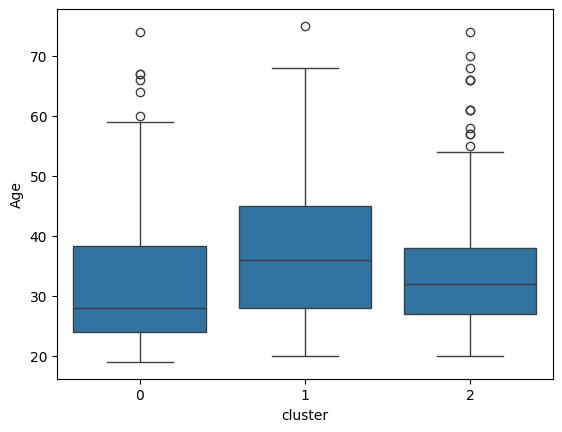

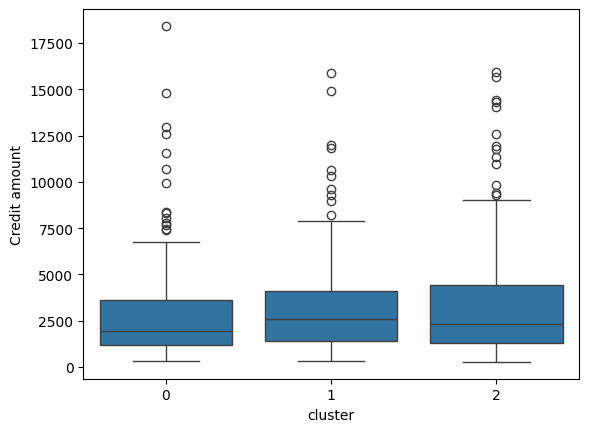

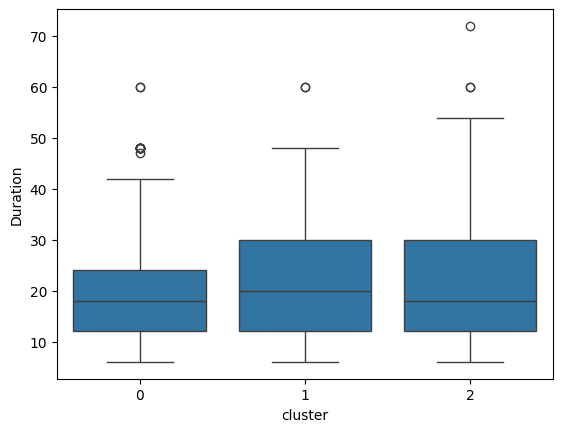

Age  ...                                            Purpose
              mean  ...                                             unique
cluster             ...                                                   
0        32.720238  ...  [radio/TV, car, business, furniture/equipment,...
1        37.566474  ...  [furniture/equipment, car, radio/TV, business,...
2        34.342541  ...  [car, radio/TV, business, domestic appliances,...

[3 rows x 27 columns]

In [237]:
numerical_box_plots(data_kmeans)
get_groupped_data(data_kmeans)

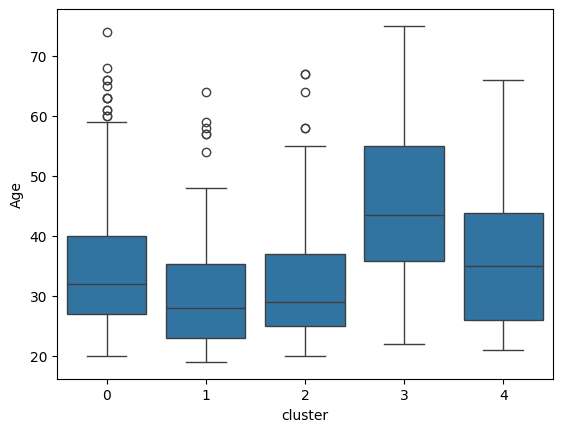

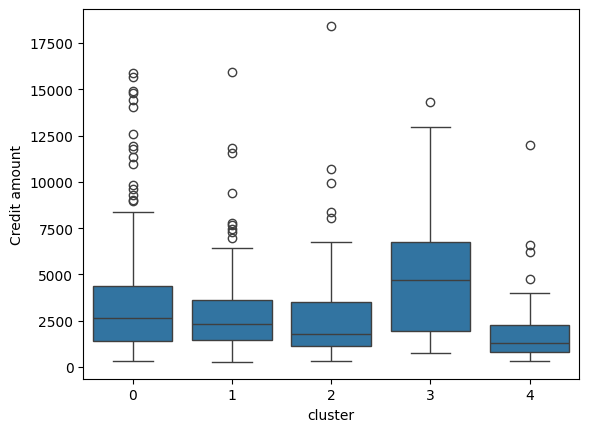

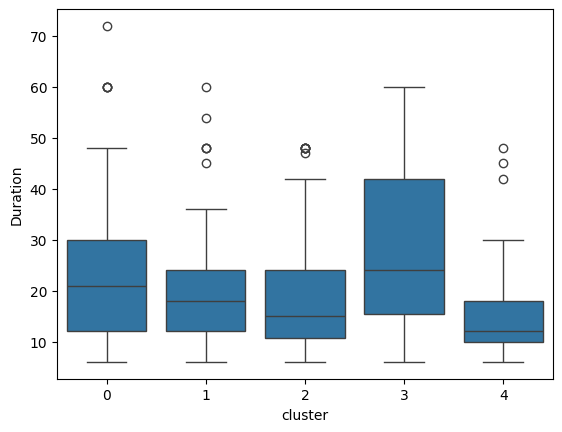

Age  ...                                            Purpose
              mean  ...                                             unique
cluster             ...                                                   
0        34.683036  ...  [car, radio/TV, business, furniture/equipment,...
1        30.531250  ...  [car, business, radio/TV, furniture/equipment,...
2        32.869048  ...  [radio/TV, furniture/equipment, business, vaca...
3        45.153846  ...  [furniture/equipment, car, business, vacation/...
4        36.409091  ...  [car, radio/TV, furniture/equipment, repairs, ...

[5 rows x 27 columns]

In [238]:
numerical_box_plots(data_ac)
get_groupped_data(data_ac)

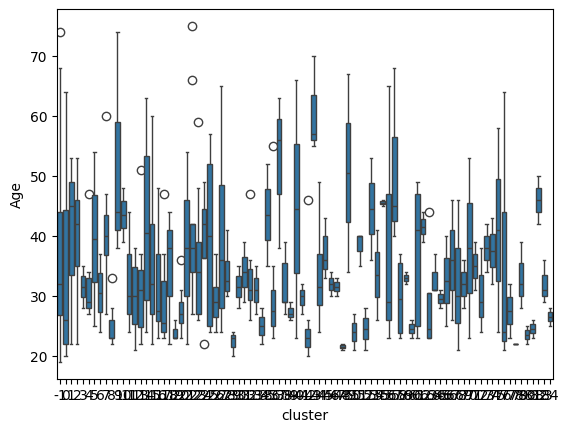

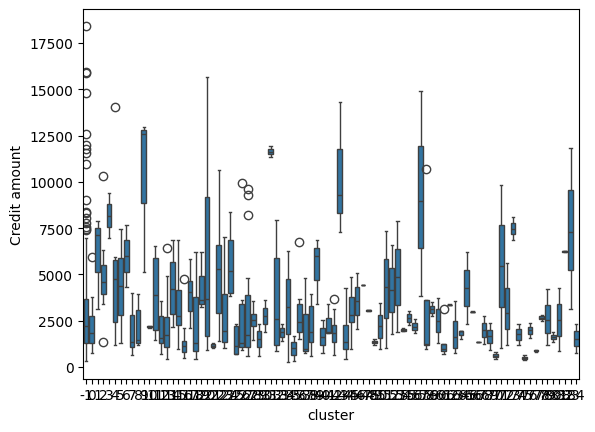

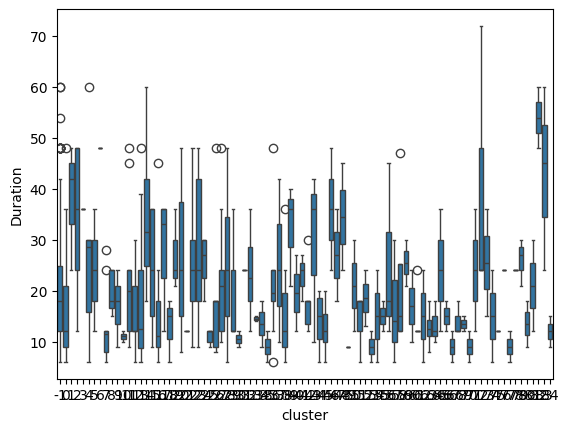

Age  ...                                            Purpose
              mean  ...                                             unique
cluster             ...                                                   
-1       36.222973  ...  [radio/TV, business, furniture/equipment, dome...
 0       33.800000  ...                                         [radio/TV]
 1       40.000000  ...                              [furniture/equipment]
 2       38.888889  ...                                              [car]
 3       31.500000  ...                                              [car]
...            ...  ...                                                ...
 80      23.500000  ...                                         [radio/TV]
 81      24.500000  ...                                         [business]
 82      46.000000  ...                                        [education]
 83      32.000000  ...                                         [business]
 84      26.500000  ...                                         [radio/TV]

[86 rows x 27 columns]

In [241]:
numerical_box_plots(data_dbscan)
get_groupped_data(data_dbscan)